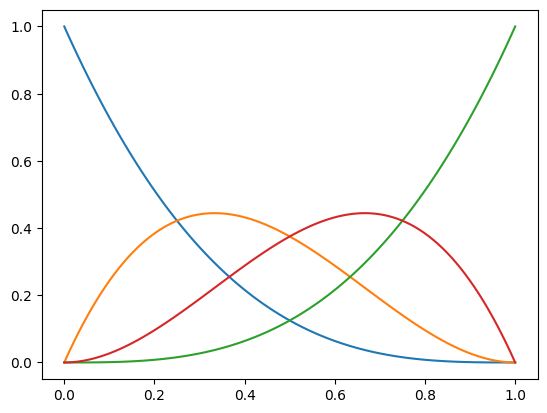

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Ejercicio 1a)
def bernstein3(t):
    matriz = []

    for valor in t:
        matriz.append([(1-valor)**3, 3*(1-valor)**2*valor, 3*(1-valor)*valor**2, valor**3])

    return np.array(matriz)

# Ejercicio 1b)

valores_de_t = np.linspace(0, 1, 100)

matriz = bernstein3(valores_de_t)

plt.plot(valores_de_t, matriz[:, 0], label="b0(t)")
plt.plot(valores_de_t, matriz[:, 1], label="b1(t)")
plt.plot(valores_de_t, matriz[:, 3], label="b3(t)")
plt.plot(valores_de_t, matriz[:, 2], label="b2(t)")

Esto se puede verificar muy facilmente viendo que que al sumar todos los polinomios de Bernstein, las "t" desaparecen:
Computacionalmente puede haber pequeños errores decimales, como ocurrió aca:

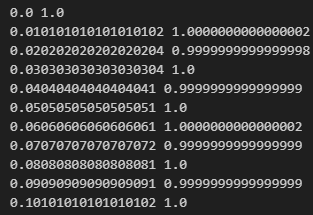

Así que usamos una tolerancia para ver si ocurre o no:

In [18]:
def suma_bernstein(t):
    b0 = (1-t)**3
    b1 = 3*(1-t)**2*t
    b2 = 3*(1-t)*t**2
    b3 = t**3

    return b0 + b1 + b2 + b3

ocurre = True
for t in valores_de_t:
    suma = suma_bernstein(t)
    if abs(suma - 1) > 0.0000001:
        ocurre = False

if ocurre:
    print("Efectivamente la suma siempre da 1 sin importar el valor de t")

Efectivamente la suma siempre da 1 sin importar el valor de t


Los polinomios de Bernstein funcionan como pesos sobre los puntos de control.
Como, para todo t entre 0 y 1, su suma es 1, cada punto de la curva de Bézier es una combinación lineal convexa de los puntos de control. Esto garantiza que la curva queda dentro del poligono convexo determinado por esos puntos.
Además, cuando t = 0, el único peso distinto de cero es el de P0, por lo que la curva comienza en P0. Cuando t = 1, el único peso distinto de cero es el de P_3, por lo que la curva termina en P_3.

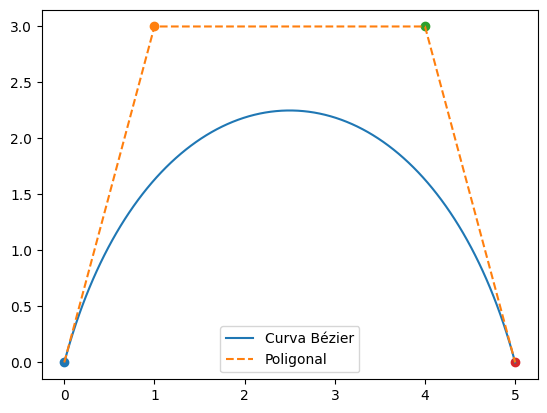

In [19]:
# Ejercicio 2a)

valores_de_t = np.linspace(0, 1, 100)
A = bernstein3(valores_de_t)

# Ejercicio 2b)

P0 = [0,0]
P1 = [1,3]
P2 = [4,3]
P3 = [5,0]

P = np.array([P0, P1, P2, P3])

# Ejercicio 2c)
C = A @ P

# Ejercicio 2d)

plt.plot(C[:,0], C[:,1], label="Curva Bézier")

plt.scatter(*P0)
plt.scatter(*P1)
plt.scatter(*P2)
plt.scatter(*P3)

plt.plot(P[:,0], P[:,1], '--', label="Poligonal")

plt.legend()
plt.show()


Dado m = 100 (valores de t entre 0 y 1):
- Por un lado la matriz A tendra dimensiones m x 4. 
- Por otro lado, P tiene dimensiones 4 x 2.
- Por ultimo, C tiene dimensiones m x 2.

La matriz A contiene 100 filas porque evaluamos la curva en 100 valores de t y 4 columnas porque hay 4 funciones de bernstein: b0(t), b1(t), b2(t) y b3(t).

P es la matriz que contiene los puntos de control. Tiene 4 filas porque hay 4 puntos de control y 2 columnas porque cada punto tiene 2 coordenadas.

C es la matriz de puntos de la curva. Tiene 100 filas porque contiene los 100 puntos calculados de la curva y 2 columnas porque cada puntos tiene 2 coordenadas.


In [20]:
A.shape
P.shape
C.shape

(100, 2)

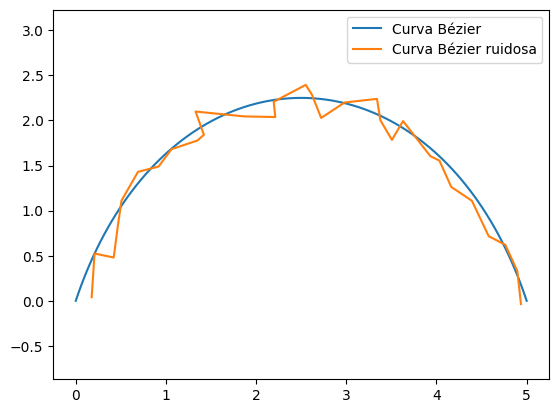

In [ ]:
# Ejercicio 3a)

valores_de_t = np.linspace(0, 1, 30)

# Ejercicio 3b)

A = bernstein3(valores_de_t)
C2 = A @ P

# Ejercicio 3c)

np.random.seed(0)

ruido = np.random.normal(0, 0.1, C2.shape)
Q = C2 + ruido

# Ejercicio 3d)

plt.plot(C[:,0], C[:,1], label="Curva Bézier")
plt.plot(Q[:,0], Q[:,1], label="Curva Bézier ruidosas")

plt.legend()
plt.axis("equal")
plt.show()


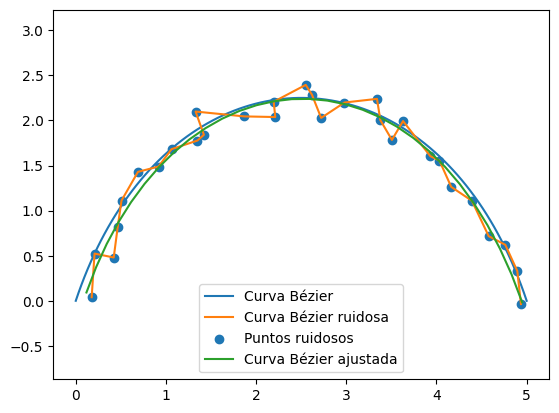

In [ ]:
# Ejercicio 4a)

A = bernstein3(valores_de_t)

# Ejercicio 4b)

# Ejercicio 4c)
P_ajustada = np.linalg.inv(A.T @ A) @ A.T @ Q
C_ajustada = A @ P_ajustada

# Ejercicio 4d)


plt.plot(C[:,0], C[:,1], label="Curva Bézier")
plt.plot(Q[:,0], Q[:,1], label="Curva Bézier ruidosa")
plt.scatter(Q[:,0], Q[:,1], label="Puntos ruidosos")
plt.plot(C_ajustada[:,0], C_ajustada[:,1], label="Curva Bézier ajustada")
plt.legend()
plt.axis("equal")
plt.show()


Podemos ver claramente en el grafico, como la curva ajustada comienza y termina en distintos puntos del grafico. Consecuentemente, ya sabemos que los puntos P0 y P3 son distintos. Para ver mejor la diferencia hacemos:

In [25]:
print("Puntos originales:")
print(P)

print("Puntos estimados:")
print(P_ajustada)

Puntos originales:
[[0 0]
 [1 3]
 [4 3]
 [5 0]]
Puntos estimados:
[[ 0.11844722  0.09233452]
 [ 1.08438595  2.87258524]
 [ 3.87610237  3.07531404]
 [ 4.94938731 -0.01537477]]


Los puntos de control estimados no son exactamente iguales a los originales. Esto ocurre porque se ajustan usando puntos observados con ruido, que no caen exactamente sobre la curva original. Además, el método de mínimos cuadrados estima los cuatro puntos de control, es decir P0 y P3 tambien, por lo que la curva ajustada puede comenzar y terminar en puntos ligeramente distintos, como vimos antes.

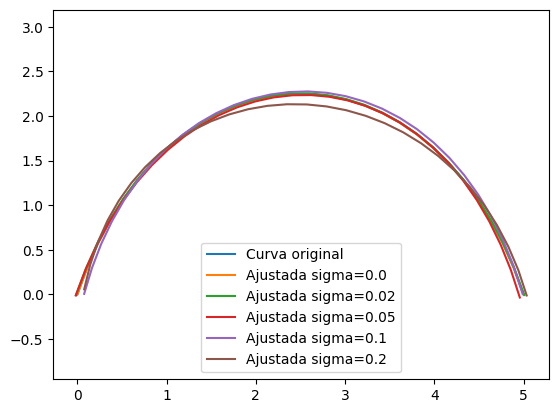

In [ ]:
#Ejercicio 4f)

sigmas = [0.00, 0.02, 0.05, 0.10, 0.20]

P_estimadas = []
C_ajustadas = []

for sigma in sigmas:
    ruido = np.random.normal(0, sigma, C2.shape)
    Q = C2 + ruido

    P_estimada = np.linalg.solve(A.T @ A, A.T @ Q)
    C_ajustada = A @ P_estimada

    P_estimadas.append(P_estimada)
    C_ajustadas.append(C_ajustada)

# Ejercicio 4g)
plt.plot(C2[:, 0], C2[:, 1], label="Curva original")

for i in range(len(sigmas)):
    plt.plot(
        C_ajustadas[i][:, 0],
        C_ajustadas[i][:, 1],
        label=f"Ajustada sigma={sigmas[i]}"
    )

plt.legend()
plt.axis("equal")
plt.show()

In [31]:
# Ejercicio 4h)

errores = []

for c in C_ajustadas:
    ECM = (1/30) * np.linalg.norm(C2 - c)**2
    errores.append(ECM)

print("sigma\tECM")
for i in range(len(sigmas)):
    print(sigmas[i], "\t", errores[i])

sigma	ECM
0.0 	 3.7684688817547334e-30
0.02 	 5.908338075102871e-05
0.05 	 0.000594489882815919
0.1 	 0.0015692487503898372
0.2 	 0.010632503431206112


A medida que aumenta el nivel de ruido, los puntos observados se van alejando cada vez mas de la curva original. Por eso, la curva ajustada también empieza a separarse más de la curva original y el ECM aumenta.

Para niveles de ruido pequeños, la curva ajustada sigue pareciendose a la curva original, porque mínimos cuadrados busca una curva que aproxime lo mejor posible a todos los puntos ruidosos.

Lo que cambia principalmente son los puntos de control estimados: dejan de coincidir con los puntos de control originales y se desplazan para compensar el ruido de los datos. Cuanto mayor es el ruido, mayor es la diferencia entre los puntos de control originales y los estimados.

# Ejercicio 5a

$$
E(p)=\|Ap-q\|^2
$$

$$
E(p)=(Ap-q)^T(Ap-q)
$$

Como:

$$
(Ap-q)^T=(Ap)^T-q^T
$$

y además:

$$
(Ap)^T=p^TA^T
$$

se obtiene:

$$
E(p)=(p^TA^T-q^T)(Ap-q)
$$

Aplicamos distributiva:

$$
E(p)=p^TA^TAp-p^TA^Tq-q^TAp+q^Tq
$$

Los términos del medio son escalares y son iguales:

$$
p^TA^Tq=q^TAp
$$

Por lo tanto:

$$
E(p)=p^TA^TAp-2q^TAp+q^Tq
$$

La parte cuadrática es:

$$
\boxed{p^TA^TAp}
$$

porque es el término donde la variable p aparece multiplicada dos veces.


In [32]:
# Ejercicio 5c y 5d

ATA = A.T @ A

print("A.T @ A:")
print(ATA)

print("¿Es simétrica?")
print(np.allclose(ATA, ATA.T))

autovalores, autovectores = np.linalg.eigh(ATA)

print("Valores propios:")
print(autovalores)

A.T @ A:
[[4.66009169 2.06281813 0.82856733 0.20714354]
 [2.06281813 2.485702   1.86429185 0.82856733]
 [0.82856733 1.86429185 2.485702   2.06281813]
 [0.20714354 0.82856733 2.06281813 4.66009169]]
¿Es simétrica?
True
Valores propios:
[0.25824389 1.70568592 4.8161144  7.51154315]


Los valores propios de $$A^TA$$ son positivos. Por lo tanto es definida positiva.

Entonces, la función de error

$$
E(p)=p^TA^TAp-2q^TAp+q^Tq
$$

es una función cuadrática convexa.

Geométricamente, la funcion deberia verse asi, como vimos en clase:

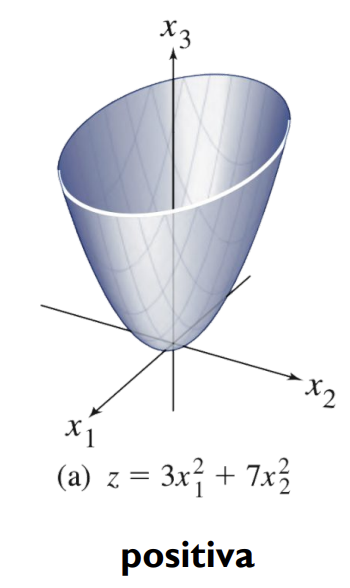

por lo que posee un mínimo global. Esto explica por qué el ajuste por mínimos cuadrados permite encontrar una curva ajustada que minimiza el error.

In [34]:
# Ejercicio 6a)

def gradiente(p, A, q):
    return 2 * A.T @ (A @ p - q)

# Ejercicio 6b)

p_inicial = np.array([0, 0, 0, 0])
grad_inicial = gradiente(p_inicial, A, Q[:, 0])

print(grad_inicial)

# Ejercicio 6c)
p_sombrerito = np.linalg.solve(A.T @ A, A.T @ Q[:, 0])

grad_p_somb = gradiente(p_sombrerito, A, Q[:, 0])

print("Solución p sombrerito:")
print(p_sombrerito)

print("Gradiente en p sombrerito:")
print(grad_p_somb)

# Ejercicio 6d)
print("Norma del gradiente en p sombrerito:")
print(np.linalg.norm(grad_p_somb))

print("¿Es aproximadamente cero?")
print(np.allclose(grad_p_somb, 0))

[-12.41122213 -27.55919287 -44.26592037 -65.44324041]
Solución p sombrerito:
[0.07668099 0.63207138 4.22584389 5.03528186]
Gradiente en p sombrerito:
[ 4.66655298e-15 -3.44915941e-15 -3.65892860e-15  9.99200722e-15]
Norma del gradiente en p sombrerito:
1.2120288119185332e-14
¿Es aproximadamente cero?
True


$$
\nabla E(p)=2A^T(Ap-q)
$$

Para encontrar el mínimo, imponemos que el gradiente sea cero:

$$
\nabla E(p)=0
$$

Entonces:

$$
2A^T(Ap-q)=0
$$

$$
A^T(Ap-q)=0
$$

Distribuyendo:

$$
A^TAp-A^Tq=0
$$
$$
A^TAp=A^Tq
$$


[0.5488135  0.71518937 0.60276338 0.54488318]
P actualizado:  [0.58002321 0.90108031 0.95721587 1.10953834]
[0.07497536 0.63786813 4.22004715 5.0369875 ]


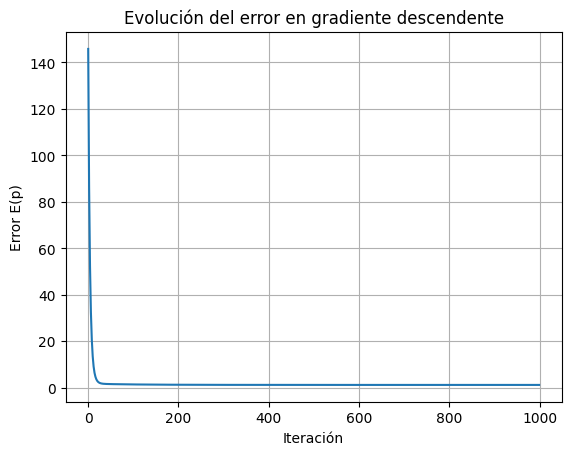

In [35]:
# Ejercicio 7a)
np.random.seed(0)
p = np.random.rand(4)
print(p)

# Ejercicio 7b)

alpha = 0.01
p = p - alpha * gradiente(p, A, Q[:, 0])
print("P actualizado: ", p)

# Ejercicio 7c y d)
def error(p, A, q):
    return np.linalg.norm(A @ p - q)**2

errores = []

for i in range(1000):
    errores.append(error(p, A, Q[:, 0]))
    p = p - alpha * gradiente(p, A, Q[:, 0])

p_gd = p
print(p_gd)

plt.plot(errores)

plt.xlabel("Iteración")
plt.ylabel("Error E(p)")
plt.title("Evolución del error en gradiente descendente")
plt.grid(True)
plt.show()

Solución por ecuaciones normales:
[0.07668099 0.63207138 4.22584389 5.03528186]
Solución por gradiente descendente:
[0.07497536 0.63786813 4.22004715 5.0369875 ]
Diferencia:
[-0.00170563  0.00579674 -0.00579674  0.00170563]
Norma de la diferencia:
0.008545338566209261


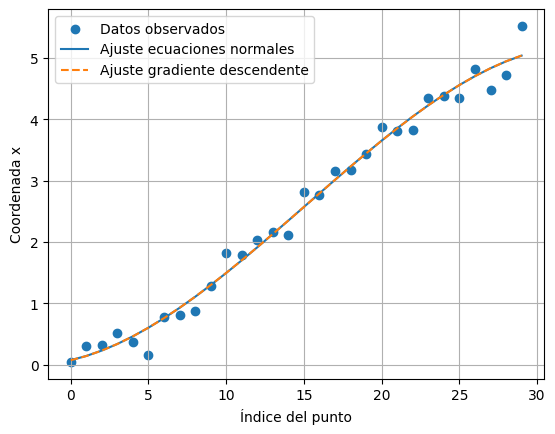

In [39]:
# Ejercicio 7e)

p_normal = np.linalg.solve(A.T @ A, A.T @ Q[:, 0])

print("Solución por ecuaciones normales:")
print(p_normal)

print("Solución por gradiente descendente:")
print(p_gd)

print("Diferencia:")
print(p_gd - p_normal)

print("Norma de la diferencia:")
print(np.linalg.norm(p_gd - p_normal))

# grafico

curva_gd = A @ p_gd
curva_normal = A @ p_normal

plt.scatter(range(len(Q[:, 0])), Q[:, 0], label="Datos observados")
plt.plot(curva_normal, label="Ajuste ecuaciones normales")
plt.plot(curva_gd, "--", label="Ajuste gradiente descendente")

plt.xlabel("Índice del punto")
plt.ylabel("Coordenada x")
plt.legend()
plt.grid(True)
plt.show()

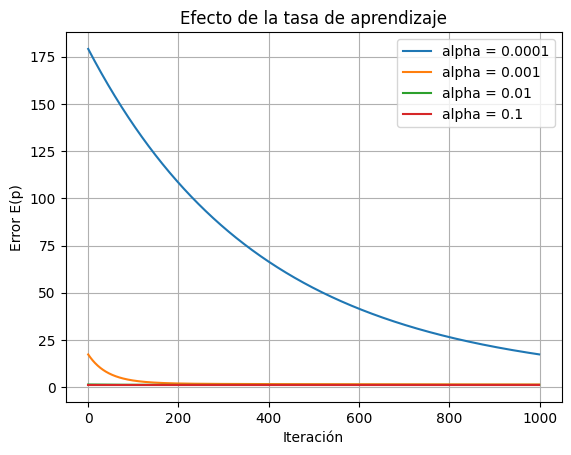

In [40]:
# Ejercicio 8a)

alphas = [1e-4, 1e-3, 1e-2, 1e-1]
iteraciones = 1000

errores_por_alpha = {}
soluciones_por_alpha = {}

p0 = np.random.rand(4)

for alpha in alphas:
    errores = []

    for i in range(iteraciones):
        errores.append(error(p0, A, Q[:, 0]))
        p0 = p0 - alpha * gradiente(p0, A, Q[:, 0])

    errores_por_alpha[alpha] = errores
    soluciones_por_alpha[alpha] = p0
    
# Ejercicio 8b)

for alpha in alphas:
    plt.plot(errores_por_alpha[alpha], label=f"alpha = {alpha}")

plt.xlabel("Iteración")
plt.ylabel("Error E(p)")
plt.title("Efecto de la tasa de aprendizaje")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
# Ejercicio 8c)
print("Errores finales:")

for alpha in alphas:
    print("alpha =", alpha, "error final =", errores_por_alpha[alpha][-1])

Errores finales:
alpha = 0.0001 error final = 17.35618383699741
alpha = 0.001 error final = 1.4137886615042146
alpha = 0.01 error final = 1.1788220698280885
alpha = 0.1 error final = 1.1788145320219254


Para alpha = 1e-4 converge más lento porque los pasos son muy chicos.

In [ ]:
# Ejercicio 8d)
for alpha in alphas:
    errores = errores_por_alpha[alpha]

    if errores[-1] > errores[0]:
        print("Con alpha =", alpha, "el método parece divergir.")
    else:
        print("Con alpha =", alpha, "el método no parece divergir.")

Con alpha = 0.0001 el método no parece divergir.
Con alpha = 0.001 el método no parece divergir.
Con alpha = 0.01 el método no parece divergir.
Con alpha = 0.1 el método no parece divergir.


In [43]:
# Ejercicio 8e)
# Comparar soluciones finales

p_normal = np.linalg.solve(A.T @ A, A.T @ Q[:, 0])

print("Solución por ecuaciones normales:")
print(p_normal)

for alpha in alphas:
    print()
    print("alpha =", alpha)
    print("Solución por gradiente descendente:")
    print(soluciones_por_alpha[alpha])
    print("Diferencia con ecuaciones normales:")
    print(np.linalg.norm(soluciones_por_alpha[alpha] - p_normal))

Solución por ecuaciones normales:
[0.07668099 0.63207138 4.22584389 5.03528186]

alpha = 0.0001
Solución por gradiente descendente:
[0.35702813 1.54603393 2.3921515  3.98427828]
Diferencia con ecuaciones normales:
2.319689281260262

alpha = 0.001
Solución por gradiente descendente:
[-0.11178745  1.27687115  3.57720459  5.22726131]
Diferencia con ecuaciones normales:
0.9533499528427359

alpha = 0.01
Solución por gradiente descendente:
[0.0756082  0.63571736 4.22219792 5.03635465]
Diferencia con ecuaciones normales:
0.005374753683919407

alpha = 0.1
Solución por gradiente descendente:
[0.07668099 0.63207138 4.22584389 5.03528186]
Diferencia con ecuaciones normales:
3.96594057820105e-15
